In [1]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import csv
import plotly.figure_factory as ff

In [2]:
def qq_func(list1: list[float], list2: list[float]):
    # Создаем 100 точек от 0 до 100 (процентили)
    percentiles = np.linspace(0, 100, 100)
    q1 = np.percentile(list1, percentiles)
    q2 = np.percentile(list2, percentiles)
    
    # --- 3. Построение графика в Plotly ---
    fig = go.Figure()
    
    # Добавляем точки квантилей (Scatter plot)
    fig.add_trace(go.Scatter(
        x=q1, 
        y=q2, 
        mode='markers',
        name='Квантили групп',
        marker=dict(color='royalblue', size=7, opacity=0.8)
    ))
    
    # Добавляем опорную линию (y = x)
    # Если распределения одинаковые, точки лягут ровно на эту красную пунктирную линию
    min_val = min(min(q1), min(q2))
    max_val = max(max(q1), max(q2))
    
    fig.add_trace(go.Scatter(
        x=[min_val, max_val], 
        y=[min_val, max_val], 
        mode='lines',
        name='Опорная линия (y=x)',
        line=dict(color='red', dash='dash', width=2)
    ))
    
    # Настраиваем внешний вид (Layout)
    fig.update_layout(
        title='Two-Sample Q-Q Plot: Сравнение двух списков данных',
        xaxis_title='Квантили Базовый контекст',
        yaxis_title='Квантили Модификация',
        width=700,
        height=700,
        template='plotly_white',  # Светлая тема
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
    )
    return fig

In [3]:
def read_df(path: str):
    df = pd.read_csv(path, quoting=csv.QUOTE_NONNUMERIC, index_col=0)
    df.index = df.index.astype(int)
    return df

- in_perturb_0 - first - perturb5
- in_perturb_1 - mean - perturb5
- in_perturb_2 - first - perturb10
- in_perturb_3 - mean - perturb10

In [4]:
in_checks = "../data/samples_50/test1/checks.csv"
in_perturb_0 = "../data/samples_50/test1/metrics1/perturb1/generate/ptb_results.csv"
in_perturb_1 = "../data/samples_50/test1/metrics2/perturb1/generate/ptb_results.csv"
in_perturb_2 = "../data/samples_50/test1/metrics1/perturb2/generate/ptb_results.csv"
in_perturb_3 = "../data/samples_50/test1/metrics2/perturb2/generate/ptb_results.csv"

base = read_df(in_checks)
perturb_0 = read_df(in_perturb_0)
perturb_1 = read_df(in_perturb_1)
perturb_2 = read_df(in_perturb_2)
perturb_3 = read_df(in_perturb_3)

In [5]:
# --- 1. Подготовка данных ---
# Замените эти списки на ваши реальные данные
# Для примера сгенерируем две группы (разного размера, но похожие по природе)
list1 = base["similarity"].tolist()
list2_0 = perturb_0["similarity"].tolist()
list2_1 = perturb_1["similarity"].tolist()
list2_2 = perturb_2["similarity"].tolist()
list2_3 = perturb_3["similarity"].tolist()

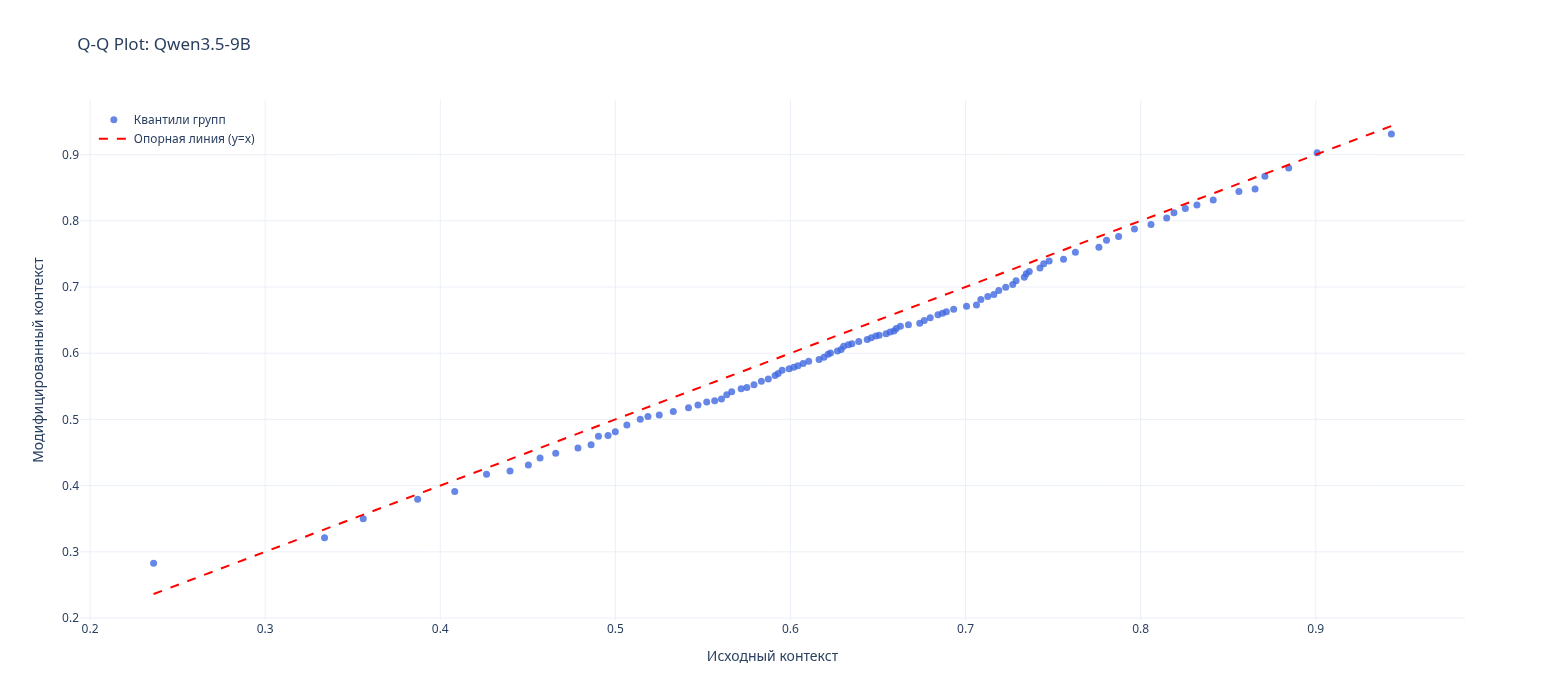

In [6]:
fig = qq_func(list1, list2_2)
# Показываем график
fig.update_layout(
    title='Q-Q Plot: Qwen3.5-9B',
    xaxis_title='Исходный контекст',
    yaxis_title='Модифицированный контекст',
)
fig.show()

- in_perturb_0 - first - perturb5
- in_perturb_1 - mean - perturb5
- in_perturb_2 - first - perturb10
- in_perturb_3 - mean - perturb10

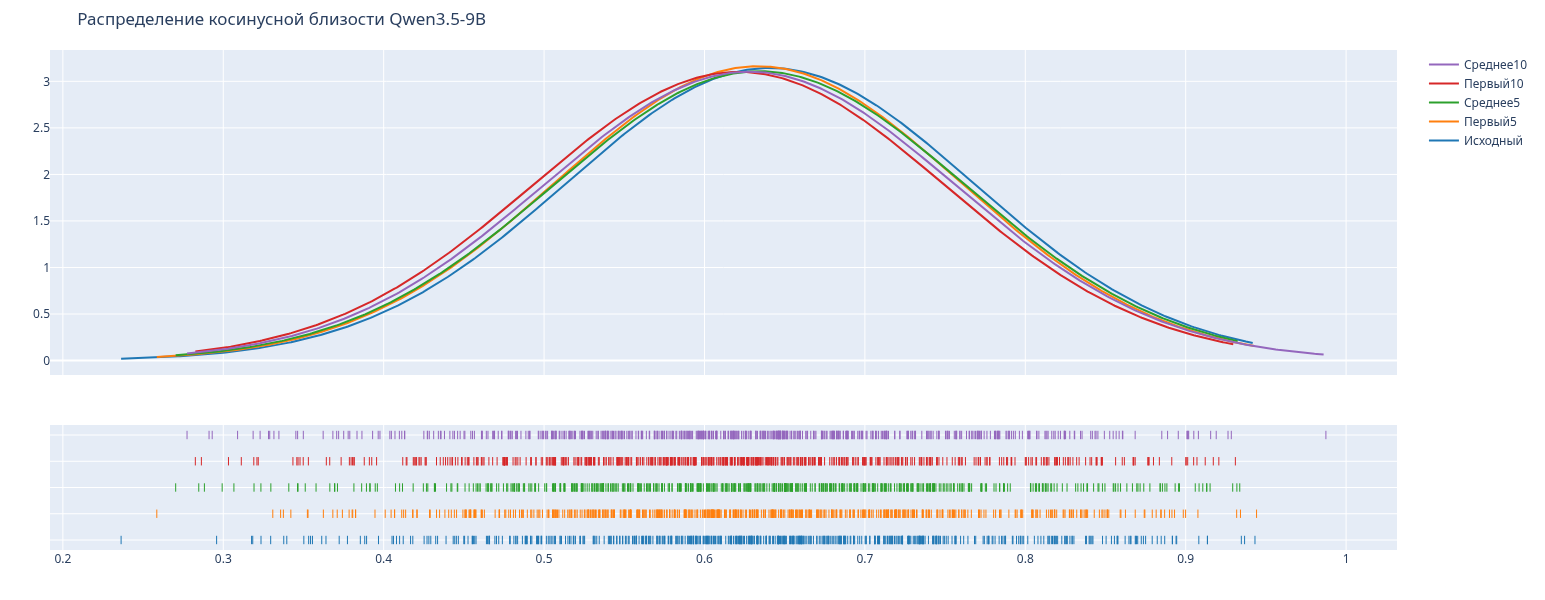

In [7]:
group_labels = ['Исходный', 'Первый5', 'Среднее5', 'Первый10', 'Среднее10']

# Create distplot with curve_type set to 'normal'
fig = ff.create_distplot(
    [
        base["similarity"],
        perturb_0["similarity"],
        perturb_1["similarity"],
        perturb_2["similarity"],
        perturb_3["similarity"],
    ], group_labels, 
    bin_size=.01,
    curve_type='normal', # override default 'kde'
    show_hist=False,
    rug_text=[
        base.index,
        perturb_0.index,
        perturb_1.index,
        perturb_2.index,
        perturb_3.index,
    ]
)

# Add title
fig.update_layout(title_text='Распределение косинусной близости Qwen3.5-9B')
# 3. Настраиваем ширину, высоту и другие параметры макета
fig.update_layout(
    width=1200,   # Ширина в пикселях
    height=600,  # Высота в пикселях
    margin=dict(l=50, r=50, t=50, b=50) # Отступы от краев (опционально)
)
fig.show()

In [23]:
group_labels = ['Исходный', 'Первый5', 'Среднее5', 'Первый10', 'Среднее10']
group_values = [
    base["similarity"],
    perturb_0["similarity"],
    perturb_1["similarity"],
    perturb_2["similarity"],
    perturb_3["similarity"],
]

In [26]:
# Преобразуем каждый список в pd.Series и объединяем по столбцам (axis=1)
df = pd.concat([pd.Series(v, name=k) for k, v in zip(group_labels, group_values)], axis=1)

# Получаем статистики распределения
stats = df.describe().round(4)

stats

,Исходный,Первый5,Среднее5,Первый10,Среднее10
count,549.0000,549.0000,549.0000,549.0000,549.0000
mean,0.6408,0.6334,0.6342,0.6213,0.6281
std,0.1270,0.1263,0.1285,0.1287,0.1287
min,0.2363,0.2586,0.2703,0.2826,0.2774
25%,0.5631,0.5475,0.5437,0.5344,0.5400
50%,0.6410,0.6297,0.6372,0.6188,0.6290
75%,0.7272,0.7208,0.7218,0.7044,0.7131
max,0.9432,0.9442,0.9337,0.9310,0.9874


In [27]:
stats.T

,count,mean,std,min,25%,50%,75%,max
Исходный,549.0,0.6408,0.1270,0.2363,0.5631,0.6410,0.7272,0.9432
Первый5,549.0,0.6334,0.1263,0.2586,0.5475,0.6297,0.7208,0.9442
Среднее5,549.0,0.6342,0.1285,0.2703,0.5437,0.6372,0.7218,0.9337
Первый10,549.0,0.6213,0.1287,0.2826,0.5344,0.6188,0.7044,0.9310
Среднее10,549.0,0.6281,0.1287,0.2774,0.5400,0.6290,0.7131,0.9874


### считаем t-парный

In [8]:
from scipy import stats

In [10]:
def compare_normal_distributions(
    sample_a: np.ndarray, 
    sample_b: np.ndarray, 
    alpha: float = 0.05
) -> tuple[float, float, str]:
    """
    Сравнивает два нормальных распределения, автоматически выбирая 
    между критерием Стьюдента и критерием Уэлча на основе дисперсий.
    """
    # 1. Проверка гомогенности дисперсий (Критерий Левена)
    # Нулевая гипотеза: дисперсии равны
    stat_levene, p_levene = stats.levene(sample_a, sample_b)
    
    # Если p_levene > alpha, мы не можем отвергнуть нулевую гипотезу (дисперсии равны)
    equal_variances = bool(p_levene > alpha)
    
    # 2. Расчет t-критерия
    # Параметр equal_var=False автоматически применяет поправку Уэлча
    t_stat, p_val = stats.ttest_ind(
        sample_a, 
        sample_b, 
        equal_var=equal_variances
    )
    
    test_used = "t-критерий Стьюдента" if equal_variances else "t-критерий Уэлча"
    
    return float(t_stat), float(p_val), test_used

In [ ]:
        base["similarity"],
        perturb_3["similarity"],

In [16]:
compare_normal_distributions(base["similarity"],perturb_2["similarity"])

(2.518461716213752, 0.01192837592035789, 't-критерий Стьюдента')

In [12]:
stat_levene, p_levene = stats.levene(base["similarity"],perturb_3["similarity"])

In [13]:
stat_levene

np.float64(0.1979438700387171)

In [14]:
p_levene

np.float64(0.6564734874867326)

In [15]:
base["similarity"].shape

(549,)

In [25]:
t_statistic, p_value, test_name = compare_normal_distributions(base["similarity"],perturb_3["similarity"])

print(f"Использован: {test_name}")
print(f"t-статистика: {t_statistic:.4f}")
print(f"p-value: {p_value:.4e}")

if p_value < 0.10:
    print("Вывод: Разница между распределениями статистически значима.")
else:
    print("Вывод: Статистически значимой разницы нет.")

Использован: t-критерий Стьюдента
t-статистика: 1.6486
p-value: 9.9510e-02
Вывод: Разница между распределениями статистически значима.


In [23]:
def welch_ttest(
    sample_a: list| np.ndarray, 
    sample_b: list| np.ndarray, 
    alpha: float = 0.05
) -> tuple[float, float, bool]:
    """
    Вычисляет t-критерий Уэлча для двух независимых выборок.
    
    Аргументы:
        sample_a: Первая выборка (список или numpy array).
        sample_b: Вторая выборка (список или numpy array).
        alpha: Уровень значимости (по умолчанию 0.05).
        
    Возвращает:
        t_stat: Значение t-статистики.
        p_val: Полученное p-value.
        is_significant: True, если разница статистически значима, иначе False.
    """
    
    # Вызов t-критерия с параметром equal_var=False превращает его в критерий Уэлча
    t_stat, p_val = stats.ttest_ind(sample_a, sample_b, equal_var=False)
    
    # Проверка на статистическую значимость
    is_significant = bool(p_val < alpha)
    
    return float(t_stat), float(p_val), is_significant

In [24]:
# Сравниваем
t_statistic, p_value, significant = welch_ttest(base["similarity"],perturb_3["similarity"], alpha=0.05)

print("--- Результаты t-критерия Уэлча ---")
print(f"t-статистика: {t_statistic:.4f}")
print(f"p-value:      {p_value:.4e}")
print("-" * 35)

if significant:
    print("Вывод: Отвергаем нулевую гипотезу.")
    print("Между выборками есть статистически значимая разница.")
else:
    print("Вывод: Не отвергаем нулевую гипотезу.")
    print("Статистически значимой разницы не обнаружено.")

--- Результаты t-критерия Уэлча ---
t-статистика: 1.6486
p-value:      9.9510e-02
-----------------------------------
Вывод: Не отвергаем нулевую гипотезу.
Статистически значимой разницы не обнаружено.
